In [1]:
import polars as pl
import numpy as np
from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
import matplotlib as mpl
from numba import njit, jit
mpl.rcParams['timezone'] = 'Europe/Moscow'

from hurst import compute_Hc
import ast
import math
import pickle
from bot.utils.pair_trading import *
from bot.analysis.strategy_analysis import analyze_strategy, create_pair_trades_df
from bot.utils.coins import get_step_info, get_price_scale
from bot.utils.data import calculate_profit

from bot.core.db.postgres_manager import DBManager
from bot.config.credentials import host, user, password, db_name
db_params = {'host': host, 'user': user, 'password': password, 'dbname': db_name}
db_manager = DBManager(db_params)

pl.Config.set_tbl_rows(20)

with open("./data/coin_information.pkl", "rb") as f:
    coin_information = pickle.load(f)

In [2]:
trading_history = db_manager.get_table('trading_history', df_type='polars').sort(by='close_time')
# trading_history = trading_history.filter(pl.col('open_time') > datetime(2025, 12, 6, 12, tzinfo=ZoneInfo('Europe/Moscow')))
trading_history.drop('open_price_1', 'open_price_2', 'close_price_1', 'close_price_2', 'leverage', 'mode', 'side_2').tail(8)

token_1,token_2,open_time,close_time,side_1,qty_1,qty_2,fee_1,fee_2,pnl_1,pnl_2,profit,reason
str,str,"datetime[μs, Europe/Moscow]","datetime[μs, Europe/Moscow]",str,f64,f64,f64,f64,f64,f64,f64,str
"""WLD""","""XTZ""",2025-12-11 13:26:10 MSK,2025-12-12 16:20:21 MSK,"""long""",169.6,202.1,-0.232664,-0.283057,3.127015,-1.659328,1.467688,"""target"""
"""RUNE""","""THETA""",2025-12-12 01:15:30 MSK,2025-12-12 17:56:11 MSK,"""long""",146.8,286.2,-0.212765,-0.198149,-2.188035,-4.433909,-6.621944,"""sl_zscore"""
"""DRIFT""","""OP""",2025-12-11 06:20:30 MSK,2025-12-12 18:03:54 MSK,"""long""",477.0,324.8,-0.182503,-0.189644,-2.567503,-3.535084,-6.102587,"""manual"""
"""IMX""","""JUP""",2025-12-11 13:02:45 MSK,2025-12-12 18:42:31 MSK,"""short""",359.8,468.0,-0.197698,-0.21435,2.680702,-4.05195,-1.371248,"""target"""
"""THETA""","""WIF""",2025-12-12 18:07:30 MSK,2025-12-12 22:37:31 MSK,"""short""",277.9,253.0,-0.195972,-0.200573,5.306798,-3.793173,1.513625,"""target"""
"""ARB""","""DOGE""",2025-12-12 20:01:20 MSK,2025-12-13 01:41:11 MSK,"""long""",497.1,737.0,-0.201872,-0.200648,2.631598,-1.342998,1.288599,"""target"""
"""ATOM""","""ORDI""",2025-12-12 08:06:25 MSK,2025-12-13 10:34:21 MSK,"""long""",45.8,23.59,-0.092289,-0.178812,-0.733489,-9.331732,-10.065222,"""sl_profit"""
"""FLOW""","""HBAR""",2025-12-12 21:24:50 MSK,2025-12-13 15:10:24 MSK,"""long""",510.7,807.0,-0.116585,-0.213014,0.649465,-0.277574,0.37189,"""target"""


In [3]:
pos_trades = trading_history.filter(pl.col('profit') > 0)
neg_trades = trading_history.filter(pl.col('profit') < 0)
print(f'Суммарный профит: {trading_history['profit'].sum():.1f}$')
print(f'Cредний профит  : {trading_history['profit'].mean():.2f}$')
print(f'Количество плюсовых сделок : {pos_trades.height}, cредний профит:  {pos_trades['profit'].mean():.2f}$')
print(f'Количество минусовых сделок: {neg_trades.height}, средний убыток: {neg_trades['profit'].mean():.2f}$')

Суммарный профит: -43.9$
Cредний профит  : -0.41$
Количество плюсовых сделок : 64, cредний профит:  2.03$
Количество минусовых сделок: 44, средний убыток: -3.95$


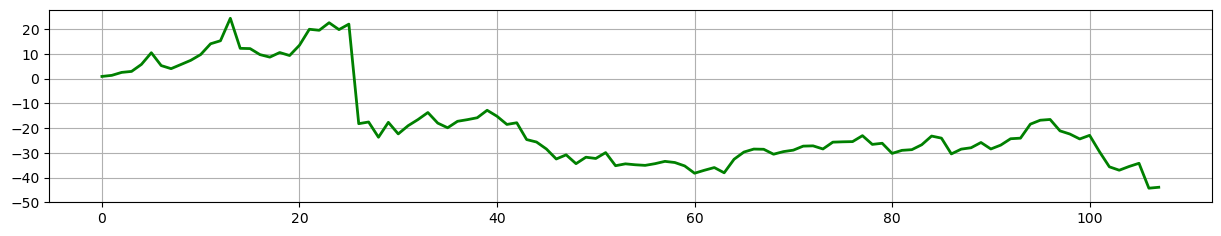

In [4]:
plt.figure(figsize=(15, 2.5))
plt.plot(trading_history['profit'].cum_sum(), c='green', linewidth=2)
plt.yticks(np.arange(-50, 30, 10))
# plt.yticks(np.arange(-5, 20, 5))
plt.grid();

In [ ]:
trading_history.group_by('token_1', 'token_2').agg(
    pl.col('profit').sum().round(2),
    pl.col('profit').min().round(2).alias('min_profit'),
    pl.col('profit').max().round(2).alias('max_profit'),
    (pl.col('profit').sum() / pl.col('profit').len()).round(2).alias('avg_profit'),
    pl.col('profit').len().alias('n_trades'),
).sort(by='n_trades', descending=True)

In [ ]:
# token_list = []
# for row in trading_history.select('token_1', 'token_2').unique().iter_rows(named=True):
#     token_list.append((row['token_1'], row['token_2']))

In [ ]:
def create_report(token_1: str,
                  token_2: str,
                  tf: str,
                  wind: int,
                  thresh_in: float,
                  thresh_out: float,
                  open_time: datetime,
                  close_time: datetime,
                  sl_usdt_ratio: float,
                  sl_std: float,
                  tp_ratio: float,
                  fee_rate: float,
                  hours_back: int,
                  coin_information: dict,
                  verbose: bool = True,
                  plot_graph: bool = True
                  ):

    # ------ Загрузка данных торговой сделки ------
    open_ts = int(datetime.timestamp(open_time))
    close_ts = int(datetime.timestamp(close_time))
    winds = np.array((wind, ))

    trading_history = db_manager.get_table('trading_history', df_type='polars')
    z_score_hist = db_manager.get_zscore_history(token_1 + '_USDT', token_2 + '_USDT', open_ts, close_ts)
    z_score_hist = z_score_hist.with_columns(
        pl.rolling_corr(a="profit", b="z_score", window_size=72000, min_samples=60, ddof=1).alias("corr"),
        pl.rolling_corr(a="profit", b="fixed_z_score", window_size=72000, min_samples=60, ddof=1).alias("fixed_corr")
        )
    
    stats = pl.read_parquet('./data/pair_selection/all_pairs.parquet').filter(
                (pl.col('coin1') == token_1) & (pl.col('coin2') == token_2) | 
                (pl.col('coin1') == token_2) & (pl.col('coin2') == token_1)
            )
    data = trading_history.filter(
            (pl.col('token_1') == token_1) & (pl.col('token_2') == token_2) & 
            (abs(pl.col('open_time') - open_time) < timedelta(seconds=10))
        )

    side_1 = data['side_1'][0]
    side_2 = data['side_2'][0]
    leverage = int(data['leverage'][0])
    median_length = 6

    # Реальный размер позиции
    t1_qty = data['qty_1'][0]
    t2_qty = data['qty_2'][0]

    t1_op = data['open_price_1'][0]
    t2_op = data['open_price_2'][0]
    t1_cp = data['close_price_1'][0]
    t2_cp = data['close_price_2'][0]

    t1_profit = data['pnl_1'][0]
    t2_profit = data['pnl_2'][0]
    total_profit = t1_profit + t2_profit

    # ------ Подготовка датафреймов ------
    tick_df, agg_df = load_data(token_1, token_2, open_time, close_time, tf, wind, db_manager)
    dist_df = create_zscore_df(token_1, token_2, tick_df, agg_df, tf, np.array([wind]), open_ts, 
                median_length=6, spr_method='dist').rename({f'z_score_{wind}_{tf}': 'z_score'})
    lr_df = create_zscore_df(token_1, token_2, tick_df, agg_df, tf, np.array([wind]), open_ts, 
        median_length=6, spr_method='lr').rename({
            f'spread_{wind}_{tf}': 'spread',
            f'spread_mean_{wind}_{tf}': 'spread_mean', 
            f'spread_std_{wind}_{tf}': 'spread_std', 
            f'z_score_{wind}_{tf}': 'z_score'
        })

    # ----- Статы на момент открытия позиции -----
    open_time_stats = get_open_time_stats(token_1, token_2, side_1, open_time, hours_back, coin_information, db_manager)

    hurst_wind = open_time_stats['hurst_wind']
    spread_rsi = open_time_stats['spread_rsi']
    rsi_long = open_time_stats['rsi_long']
    rsi_short = open_time_stats['rsi_short']
    
    profit_z_corr = open_time_stats['profit_z_corr']
    corr_wind = open_time_stats['corr_wind']
    corr_hb = open_time_stats['corr_hb']
    corr_5m = open_time_stats['corr_5m']

    half_life_log_spread = open_time_stats['half_life_log_spread']

    std_1_wind = open_time_stats['long_std_wind'] if side_1 == 'long' else open_time_stats['short_std_wind']
    std_2_wind = open_time_stats['short_std_wind'] if side_1 == 'long' else open_time_stats['long_std_wind']
    std_1_hb = open_time_stats['long_std_hb'] if side_1 == 'long' else open_time_stats['short_std_hb']
    std_2_hb = open_time_stats['short_std_hb'] if side_1 == 'long' else open_time_stats['long_std_hb']
    std_1_5m = open_time_stats['long_std_5m'] if side_1 == 'long' else open_time_stats['short_std_5m']
    std_2_5m = open_time_stats['short_std_5m'] if side_1 == 'long' else open_time_stats['long_std_5m']

    beta_wind = open_time_stats['beta_wind']
    beta_hb = open_time_stats['beta_hb']

    potential_profit_mean = open_time_stats['potential_profit_mean']
    potential_profit_min = open_time_stats['potential_profit_min']
    potential_profit_max = open_time_stats['potential_profit_max']
    
    potential_loss_mean = open_time_stats['potential_loss_mean']
    potential_loss_min = open_time_stats['potential_loss_min']
    potential_loss_max = open_time_stats['potential_loss_max']
    
    pl_ratio_mean = open_time_stats['pl_ratio_mean']
    pl_ratio_worst = open_time_stats['pl_ratio_worst']
    pl_ratio_best = open_time_stats['pl_ratio_best']

    dist_potential_profit_mean = open_time_stats['dist_potential_profit_mean']

    dist_z_score = open_time_stats['dist_z_curr']
    
    # Размер открытой позиции
    total_pos_side = round(t1_qty * t1_op + t2_qty * t2_op)
    
    # ----- Расчёт профита при бета-нейтральной позиции -----
    # TLS 180d
    tls_beta = stats['tls_beta'][0]
    t1_qty_tls_l, t2_qty_tls_l = get_qty(token_1, token_2, t1_op, t2_op, tls_beta, coin_information, total_pos_side, method='beta_neutral')
    bn_tls_l = calculate_profit_curve(lr_df, token_1, token_2, side_1, t1_op, t2_op, t1_qty_tls_l, t2_qty_tls_l, fee_rate=0.001)
    bn_tls_l_profit = bn_tls_l['profit'][-1]
    
    # TLS beta 2 * {wind} days
    tls_beta_w = open_time_stats['tls_beta_wind']
    t1_qty_tls_w, t2_qty_tls_w = get_qty(token_1, token_2, t1_op, t2_op, tls_beta_w, coin_information, total_pos_side, method='beta_neutral')
    bn_tls_w = calculate_profit_curve(lr_df, token_1, token_2, side_1, t1_op, t2_op, t1_qty_tls_w, t2_qty_tls_w, fee_rate=0.001)
    bn_tls_w_profit = bn_tls_w['profit'][-1]

    # 2 hours
    tls_beta_hb = open_time_stats['tls_beta_hb']
    t1_qty_tls_hb, t2_qty_tls_hb = get_qty(token_1, token_2, t1_op, t2_op, tls_beta_hb, coin_information, 
                                           total_pos_side, method='beta_neutral')
    bn_tls_hb = calculate_profit_curve(lr_df, token_1, token_2, side_1, t1_op, t2_op, t1_qty_tls_hb, t2_qty_tls_hb, fee_rate=0.001)
    bn_tls_hb_profit = bn_tls_hb['profit'][-1]
    
    # ----- Расчёт профита при volatility-нейтральной позиции -----
    # 180 days
    std_1_180d = stats['std_1'][0]
    std_2_180d = stats['std_2'][0]
    t1_qty_vnl, t2_qty_vnl = get_qty(token_1, token_2, t1_op, t2_op, beta=None, coin_information=coin_information,
                        total_usdt_amount=total_pos_side, fee_rate=fee_rate, std_1=std_1_180d, std_2=std_2_180d, method='vol_neutral')
    vn_l = calculate_profit_curve(lr_df, token_1, token_2, side_1, t1_op, t2_op, t1_qty_vnl, t2_qty_vnl, fee_rate=0.001)
    vn_l_profit = vn_l['profit'][-1]

    # {wind} days
    t1_qty_vnw, t2_qty_vnw = get_qty(token_1, token_2, t1_op, t2_op, beta=None, coin_information=coin_information,
                        total_usdt_amount=total_pos_side, fee_rate=fee_rate, std_1=std_1_wind, std_2=std_2_wind, method='vol_neutral')
    vn_w = calculate_profit_curve(lr_df, token_1, token_2, side_1, t1_op, t2_op, t1_qty_vnw, t2_qty_vnw, fee_rate=0.001)
    vn_w_profit = vn_w['profit'][-1]

    # 2 hours
    t1_qty_vnhb, t2_qty_vnhb = get_qty(token_1, token_2, t1_op, t2_op, beta=None, coin_information=coin_information,
                        total_usdt_amount=total_pos_side, fee_rate=fee_rate, std_1=std_1_hb, std_2=std_2_hb, method='vol_neutral')
    vn_hb = calculate_profit_curve(lr_df, token_1, token_2, side_1, t1_op, t2_op, t1_qty_vnhb, t2_qty_vnhb, fee_rate=0.001)
    vn_hb_profit = vn_hb['profit'][-1]
    
    # ----- stop-loss по профиту ------
    sl_profit = None
    if sl_usdt_ratio:
        pos_size = (t1_qty * t1_op + t2_qty * t2_op) / leverage
        sl_df = z_score_hist.filter(pl.col('profit') < -sl_usdt_ratio * pos_size).head(1)

        if sl_df.height > 0:
            sl_time = sl_df['time'][0]
            sl_profit = sl_df['profit'][0]

    # ----- stop-loss по предельному отклонению z_score ------
    slf_profit = None
    if sl_std:
        slf_df = z_score_hist.filter(abs(pl.col('fixed_z_score')) > sl_std).head(1)
        
        if slf_df.height > 0:
            slf_time = slf_df['time'][0]
            slf_profit = slf_df['profit'][0]


    # # take-profit
    # tp_profit = None
    # if tp_ratio:
    #     pos_size = (t1_qty * t1_op + t2_qty * t2_op) / leverage
    #     tp_idx = z_score_hist.filter(pl.col('profit') > tp_ratio * pos_size).head(1)

    #     if tp_idx.height > 0:
    #         tp_row = df.filter((m:=(pl.col('ts') - tp_idx['ts'][0]).abs()).min() == m)
    #         tp_time = tp_row['time'][0]
    #         t1_tp_close = tp_row[f'{token_1}_ask_price'][0] if side_1 == 'short' else tp_row[f'{token_1}_bid_price'][0]
    #         t2_tp_close = tp_row[f'{token_2}_bid_price'][0] if side_1 == 'short' else tp_row[f'{token_2}_ask_price'][0]

    #         tp_pr_1 = calculate_profit(open_price=t1_op, close_price=t1_tp_close, n_coins=t1_qty, side=side_1)
    #         tp_pr_2 = calculate_profit(open_price=t2_op, close_price=t2_tp_close, n_coins=t2_qty, side=side_2)
    #         tp_profit = tp_pr_1 + tp_pr_2

    # ------ Статы в процессе удержания позиции ------
    # zscore_corr = z_score_hist.select('profit', 'z_score').corr()['z_score'][0]
    # fzscore_corr = z_score_hist.select('profit', 'fixed_z_score').corr()['z_score'][0]
    

    if plot_graph:
        coef = lr_df[token_1].mean() / lr_df[token_2].mean()
        fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
    
        # --- Графики цены ---
        ax1.plot(lr_df.select('time'), lr_df.select(token_1), label=token_1, color='orange')
        ax1.set_title(f'{token_1} - {token_2} (tf: {tf}, wind: {wind}, side: {side_1}; thresh_in: {thresh_in}, thresh_out: {thresh_out})')
        ax1.set_ylabel('udst')
        ax1.legend()
        ax1.grid()
    
        ax11 = ax1.twinx()
        ax11.plot(lr_df.select('time'), lr_df.select(token_2), label=token_2, color='blue')
    
        # --- График спреда ---
        spread = dist_df[token_1].log() - dist_df[token_2].log()
        k, b = lr_coefs(spread.to_numpy())
        regression_line = k * range(spread.shape[0]) + b
    
        ax2.plot(dist_df['time'], spread)
        ax2.plot(dist_df['time'], regression_line, c='green', linewidth=2)
        ax2.set_ylabel('Spread')
        ax2.grid()
        
        # --- Графики z_score ---
        ax3.plot(dist_df.select('time'), dist_df.select(['z_score']), label='Dist calc', c='green')
        ax3.plot(z_score_hist.select('time'), z_score_hist.select('fixed_z_score'), label='fixed', c='gray', linewidth=2)
        ax3.plot(z_score_hist.select('time'), z_score_hist.select('z_score'), c='blue', label='LR real')
        ax3.set_ylabel('z_score')
        if side_1 == 'long':
            ax3.axhline(-thresh_in, c='g', linestyle='dotted')
            ax3.axhline(thresh_out, c='r', linestyle='dotted')
        else:
            ax3.axhline(thresh_in, c='g', linestyle='dotted')
            ax3.axhline(-thresh_out, c='r', linestyle='dotted')
        ax3.grid()
        ax3.legend()
    
        # --- График профита ---
        ax4.plot(bn_tls_w['time'], bn_tls_w['profit'], color='orange', label=f'TLS ({wind}h)')
        ax4.plot(bn_tls_l['time'], bn_tls_l['profit'], color='red', label='TLS (180d)')
        ax4.plot(bn_tls_hb['time'], bn_tls_hb['profit'], color='purple', label='TLS (hb)')
        ax4.plot(vn_l['time'], vn_l['profit'], color='cyan', label='Vol-neutr (180d)')
        ax4.plot(vn_w['time'], vn_w['profit'], color='blue', label=f'Vol-neutr ({wind}h)')
        ax4.plot(z_score_hist.select('time'), z_score_hist.select('profit'), color='green', label='usdt_neutral', linewidth=3)
        ax4.set_ylabel('profit')
        ax4.grid()
        ax4.legend(loc='lower left')
    
        # --- График корреляции ---
        ax5.plot(z_score_hist['time'], z_score_hist['corr'], color='blue', label='z_score - profit')
        ax5.plot(z_score_hist['time'], z_score_hist['fixed_corr'], color='green', label='fixed_z_score - profit')
        ax5.set_ylabel('Correlation')
        ax5.legend(loc='lower left')
        ax5.grid()
        
    
        plt.tight_layout()
        plt.show()

    if verbose:
        print(f'{token_1} - {token_2}. Side: {side_1}; thresh_in: {thresh_in}, thresh_out: {thresh_out}')
        print(f'[ OPEN] Время: {open_time:%Y-%m-%d %H:%M:%S}', end='; ')
        print(f'z_score: (lr) {z_score_hist['z_score'][0]:.2f}; (dist) {dist_z_score:.2f}')
        print(f'Std_ratio: (180d) {std_1_180d / std_2_180d:.4f}; ({2*wind}h) {std_1_wind / std_2_wind:.4f}', end='; ')
        print(f'(hb) {std_1_hb / std_2_hb:.4f}; (5m) {std_1_5m / std_2_5m:.4f}')
        print(f'Коэф. хеджирования (180d): tls_beta: {tls_beta:.3f}')
        print(f'Краткосрочные кэфы. Tls beta: ({2*wind}h) {tls_beta_w:.2f}; ({hours_back}h) {tls_beta_hb:.2f}', end='; ')
        print(f'LinReg beta: ({2*wind}h) {beta_wind:.2f}; ({hours_back}h) {beta_hb:.2f}')
        print(f'Показатель Хёрста: {hurst_wind:.2f}', end='. ')
        print(f'RSI. Spread: {int(spread_rsi)}, Long: {int(rsi_long)}, short: {int(rsi_short)}')
        # print(f'Процентное изменение линии регрессии за {wind} часов: {hist_trend:.1f}%')
        print(f'Half-life. Log spread: {half_life_log_spread:.1f} hours')
        # print(f'Коэф. хеджирования: beta_1: {beta_1:.3f}, beta_2: {beta_2:.3f}')
        print(f'Корреляция между профитом и z_score за 2 часа: {profit_z_corr:.2f}', end='; ')
        print(f'Между токенами: ({2*wind}h) {corr_wind:.2f}; (hb) {corr_hb:.2f}; (5m) {corr_5m:.2f}')
        print(f'Potential profit. (mean) ${potential_profit_mean:.2f}; (min): ${potential_profit_min:.2f}', end='; ')
        print(f'(max): ${potential_profit_max:.2f}')
        print(f'Potential loss: ${potential_loss_mean:.2f}; loss ratio: {pl_ratio_mean:.2f}')
        print()
        print(f'[CLOSE] Время: {close_time:%Y-%m-%d %H:%M:%S}; Цены. {token_1}: {t1_cp}; {token_2}: {t2_cp}; z_score: {z_score_hist['z_score'][-1]:.2f}')
        print(f'Corr. z_score: {z_score_hist["corr"][-1]:.2f}; fixed z_score: {z_score_hist["fixed_corr"][-1]:.2f}')
        # # print(f'Чувствительность. Общая: {np.mean(dvu_dz):.2f}; Pos: {np.mean(dvu_dz_pos):.2f}; Neg: {np.mean(dvu_dz_neg):.2f}')
        
        print()
        print(f'[PROFIT]')
        print(f'usdt-neutral: {t1_qty} {token_1}({side_1}): {t1_profit:.2f}$, {t2_qty} {token_2}({side_2}): {t2_profit:.2f}$; total profit: {total_profit:.2f}$')
        print(f'vol-neutral  (180d): {t1_qty_vnl} {token_1}, {t2_qty_vnl} {token_2}; total profit: {vn_l_profit:.2f}$')
        print(f'vol-neutral   ({wind}h): {t1_qty_vnw} {token_1}, {t2_qty_vnw} {token_2}; total profit: {vn_w_profit:.2f}$')
        print(f'vol-neutral  ( hb ): {t1_qty_vnhb} {token_1}, {t2_qty_vnhb} {token_2}; total profit: {vn_hb_profit:.2f}$')
        print(f'beta-neutral (180d): {t1_qty_tls_l} {token_1}, {t2_qty_tls_l} {token_2}; total profit: {bn_tls_l_profit:.2f}$')
        print(f'beta-neutral  ({wind}h): {t1_qty_tls_w} {token_1}, {t2_qty_tls_w} {token_2}; total profit: {bn_tls_w_profit:.2f}$')
        print(f'beta-neutral ( hb ): {t1_qty_tls_hb} {token_1}, {t2_qty_tls_hb} {token_2}; total profit: {bn_tls_hb_profit:.2f}$')
    
        if sl_profit:
            print(f'\n[STOP LOSS] Время создания ордера: {sl_time:%Y-%m-%d %H:%M:%S}')
            print(f'Profit: {sl_profit:.2f}$')
        if slf_profit:
            print(f'\n[STOP LOSS] Время создания ордера: {slf_time:%Y-%m-%d %H:%M:%S}')
            print(f'Profit: {slf_profit:.2f}$')
    
        # if tp_profit:
        #     print(f'\n[TAKE PROFIT] Время создания ордера: {tp_time:%Y-%m-%d %H:%M:%S}')
        #     print(f'Цены. {token_1}: {t1_tp_close}; {token_2}: {t2_tp_close}')
        #     print(f'Profit: {token_1}({side_1}): {tp_pr_1:.2f}$, {token_2}({side_2}): {tp_pr_2:.2f}$; total profit: {tp_profit:.2f}$')

    return {
        'total_profit': total_profit,
        'vn_l_profit': vn_l_profit,
        'vn_w_profit': vn_w_profit,
        'vn_hb_profit': vn_hb_profit,
        'bn_tls_l_profit': bn_tls_l_profit,
        'bn_tls_w_profit': bn_tls_w_profit,
        'bn_tls_hb_profit': bn_tls_hb_profit,
        'std_ratio_hb': std_1_hb / std_2_hb,
        'std_ratio_5m': std_1_5m / std_2_5m,
        'corr_wind': corr_wind,
        'corr_hb': corr_hb,
        'corr_5m': corr_5m,
        'potential_profit_mean': potential_profit_mean,
        'potential_profit_min': potential_profit_min,
        'potential_loss_mean': potential_loss_mean,
        'pl_ratio_mean': pl_ratio_mean,
        'tls_beta_hb': tls_beta_hb
        
    }

In [ ]:
#    

token_1 = 'THETA'
token_2 = 'WIF'
# start_time = "2025-12-10 00:38:20"
# end_time = "2025-12-10 18:13:16"
tf = '1h'
wind = 72
thresh_in = 2.25
thresh_out = 0.25

# open_time = datetime.strptime(start_time, '%Y-%m-%d %H:%M:%S').replace(tzinfo=ZoneInfo("Europe/Moscow"))
# close_time = datetime.strptime(end_time, '%Y-%m-%d %H:%M:%S').replace(tzinfo=ZoneInfo("Europe/Moscow"))

open_time = datetime(2025, 12, 12, 18, 7, 30, tzinfo=ZoneInfo('Europe/Moscow'))
close_time = datetime(2025, 12, 12, 22, 37, 31, tzinfo=ZoneInfo('Europe/Moscow'))

params = create_report(token_1, token_2, tf, wind, thresh_in, thresh_out, open_time, close_time, 
            sl_usdt_ratio=0.1, sl_std=8.0, tp_ratio=0.2, fee_rate=0.001, hours_back=2,
            coin_information=coin_information, plot_graph=True, verbose=True)

In [ ]:
tf = '1h'
wind = 72
thresh_in = 2.25
thresh_out = 0.25

profit_arr, vnl_arr, vnw_arr, vnhb_arr, bnl_arr, bnw_arr, bnhb_arr  = [], [], [], [], [], [], []

trading_history = db_manager.get_table('trading_history', df_type='polars').filter(
        pl.col('open_time') > datetime(2025, 11, 6, 12, tzinfo=ZoneInfo('Europe/Moscow'))
    )
for trade in trading_history.sort(by='open_time', descending=True).iter_rows(named=True):
    try:
        token_1 = trade['token_1']
        token_2 = trade['token_2']
        open_time = trade['open_time']
        close_time = trade['close_time']
        side = trade['side_1']
    
        params = create_report(
            token_1, token_2, tf, wind, thresh_in, thresh_out, open_time, close_time, sl_usdt_ratio=0.1, 
            sl_std=8.0, tp_ratio=0.2, fee_rate=0.001, hours_back=2, 
            coin_information=coin_information, plot_graph=False, verbose=False)
        
        std_ratio_hb = params['std_ratio_hb']
        std_ratio_5m = params['std_ratio_5m']
        potential_profit_mean = params['potential_profit_mean']
        potential_profit_min = params['potential_profit_min']
        tls_beta_hb = params['tls_beta_hb']
        profit = params['total_profit']
        bn_profit = params['bn_tls_hb_profit']

        if tls_beta_hb < 0.5 or tls_beta_hb > 2.0:
            print(f'{token_1:>7} - {token_2:7} ({side:>5}). {tls_beta_hb=:>6.2f}; {std_ratio_5m=:>4.2f}; profit: {profit:>6.2f}$; beta-neut profit: {bn_profit:>6.2f}$')
            continue
        elif potential_profit_mean < 0:
            print(f'{token_1:>7} - {token_2:7} ({side:>5}). {potential_profit_mean=:.4f}; profit: {params['total_profit']:.2f}$; beta-neut profit: {bn_profit:>6.2f}$')
            continue
        elif std_ratio_5m < 0.5 or std_ratio_5m > 2.0:
            print(f'{token_1:>7} - {token_2:7} ({side:>5}). {tls_beta_hb=:>6.2f}; {std_ratio_5m=:>4.2f}; profit: {profit:>6.2f}$; beta-neut profit: {bn_profit:>6.2f}$')
            continue
        else:
            profit_arr.append(profit)
            vnl_arr.append(params['vn_l_profit'])
            vnw_arr.append(params['vn_w_profit'])
            vnhb_arr.append(params['vn_hb_profit'])
            bnl_arr.append(params['bn_tls_l_profit'])
            bnw_arr.append(params['bn_tls_w_profit'])
            bnhb_arr.append(params['bn_tls_hb_profit'])
        
    except IndexError:
        print()
        print('========================================')
        print(f'Ошибка с парой {token_1} - {token_2}')
        print('========================================')
        print()
    except Exception:
        continue

In [ ]:
len(profit_arr)

In [ ]:
print('Profit.')
print(f'Usdt-neutral        : ${np.sum(profit_arr):.1f} (std: ${np.std(profit_arr):.2f})')
print(f'Vol-neutral (180d)  : ${np.sum(vnl_arr):.1f} (std: ${np.std(vnl_arr):.2f})')
print(f'Vol-neutral ({wind}h)   : ${np.sum(vnw_arr):.1f} (std: ${np.std(vnw_arr):.2f})')
print(f'Vol-neutral (hb)    : ${np.sum(vnhb_arr):.1f} (std: ${np.std(vnhb_arr):.2f})')
print(f'Beta-neutral (180d) : ${np.sum(bnl_arr):.1f} (std: ${np.std(bnl_arr):.2f})')
print(f'Beta-neutral ({wind}h)  : ${np.sum(bnw_arr):.1f} (std: ${np.std(bnw_arr):.2f})')
print(f'Beta-neutral (hb)   : ${np.sum(bnhb_arr):.1f} (std: ${np.std(bnhb_arr):.2f})')